In [235]:
print("Hello World")

Hello World


## Package import

In [236]:
# ============================================================
# 🔧 SYSTEM & UTILITIES
# ============================================================
import os
import gc
import re
import io
import psutil
import json
import joblib
import pickle
import random
import requests
import itertools
import warnings
import holidays
import urllib.request as urlreq
from tqdm import tqdm
from dotenv import load_dotenv
from datetime import datetime, timedelta, date
from dateutil.relativedelta import relativedelta

# Suppress warnings
warnings.filterwarnings('ignore')

# ============================================================
# 📦 CORE PYTHON & DATA HANDLING
# ============================================================
import numpy as np
import pandas as pd
import datetime as dt

# ============================================================
# 📊 EXPLORATORY DATA ANALYSIS (EDA) & VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import missingno as msno
from pandas.plotting import lag_plot, autocorrelation_plot
from scipy import stats
from math import sqrt
from IPython.display import display, HTML

# Enable inline plotting
%matplotlib inline

# ============================================================
# ⚙️ DATA PREPROCESSING & FEATURE ENGINEERING
# ============================================================
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, OneHotEncoder, LabelEncoder, PolynomialFeatures
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, f_classif
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# ============================================================
# 🧠 MACHINE LEARNING MODELS
# ============================================================
from sklearn.model_selection import (
    train_test_split, TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, make_scorer
)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# ============================================================
# 🔮 TIME SERIES & FORECASTING
# ============================================================
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ============================================================
# 🧬 DEEP LEARNING (TENSORFLOW / KERAS)
# ============================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Bidirectional, BatchNormalization,
    Conv1D, MaxPooling1D, Flatten
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.utils import plot_model
from tensorflow.keras import backend as K
import keras_tuner as kt

# ============================================================
# 🧮 STATISTICAL ANALYSIS
# ============================================================
import scipy.stats as stats
from scipy.stats import zscore, pearsonr, spearmanr

# ============================================================
# 🗂 DASHBOARDING & FRONT-END (OPTIONAL)
# ============================================================
import streamlit as st

# ============================================================
# ✅ SETUP COMPLETE
# ============================================================
print("✅ All essential libraries imported successfully.")


✅ All essential libraries imported successfully.


## Data Loader

In [237]:
df = pd.read_csv(r'C:\Users\TPWODL\New folder_Content\DeepLearning_TimeSeries_LSTM_End_To_End\data\raw\Energy Demand Hourly.csv')

In [238]:
df

,date,megawatthours
0,01-07-2015 05:00,162827
1,01-07-2015 06:00,335153
2,01-07-2015 07:00,333837
3,01-07-2015 08:00,398386
4,01-07-2015 09:00,388954
...,...,...
58931,21-03-2022 16:00,433344
58932,21-03-2022 17:00,429156
58933,21-03-2022 18:00,426496
58934,21-03-2022 19:00,423393


## Data core checking and cleaning

In [239]:
# -----------------------------------------------
# 1️⃣ Basic Information
# -----------------------------------------------
print("🔹 Dataset Shape:", df.shape)
print("\n🔹 Data Types:")
print(df.dtypes)
print("\n🔹 Columns:", df.columns.tolist())

🔹 Dataset Shape: (58936, 2)

🔹 Data Types:
date             object
megawatthours     int64
dtype: object

🔹 Columns: ['date', 'megawatthours']


In [240]:
# -----------------------------------------------
# 2️⃣ Missing Values & Duplicates
# -----------------------------------------------
print("\n🔹 Missing Values Count:")
print(df.isnull().sum())

print("\n🔹 Duplicate Rows:", df.duplicated().sum())


🔹 Missing Values Count:
date             0
megawatthours    0
dtype: int64

🔹 Duplicate Rows: 0



🔹 Missing Values Count:
date             0
megawatthours    0
dtype: int64

🔹 Duplicate Rows: 0


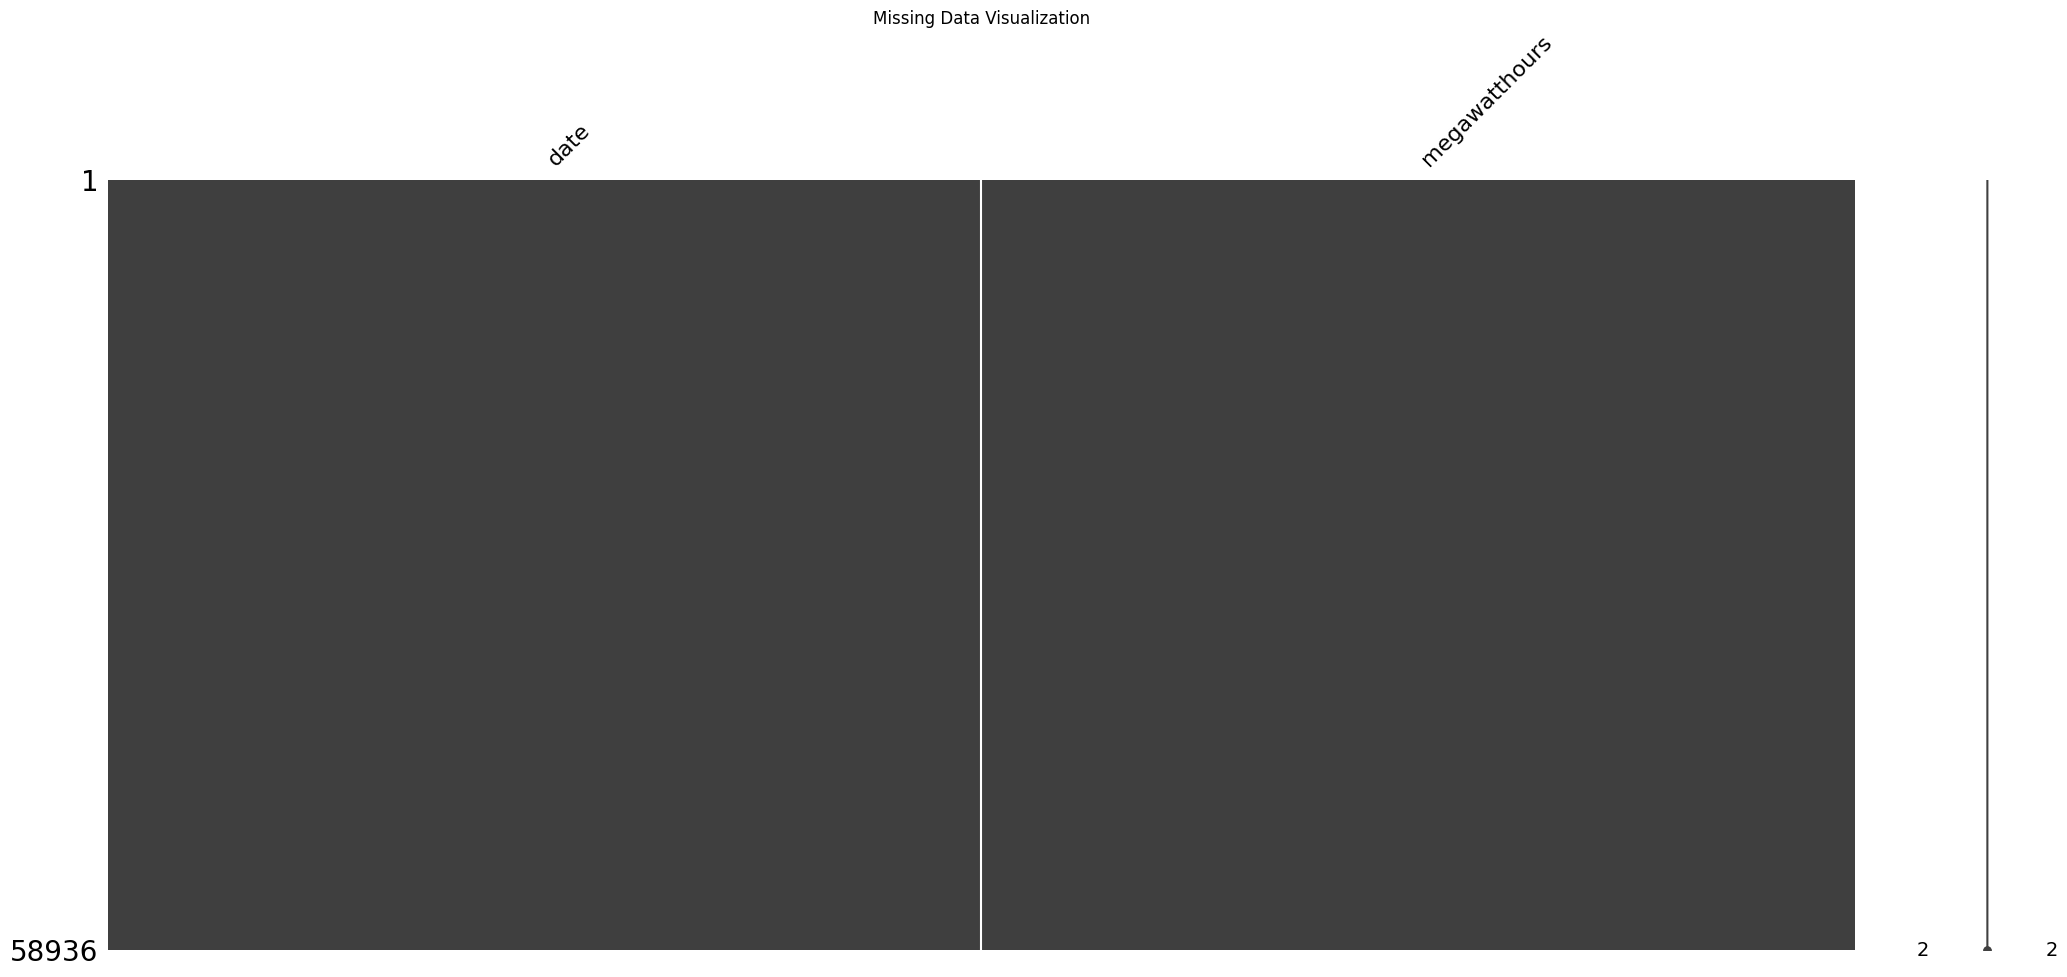

In [241]:
# -----------------------------------------------
# 2️⃣ Missing Values & Duplicates
# -----------------------------------------------
print("\n🔹 Missing Values Count:")
print(df.isnull().sum())

print("\n🔹 Duplicate Rows:", df.duplicated().sum())

# Missing data visualization
msno.matrix(df)
plt.title("Missing Data Visualization")
plt.show()

In [242]:
# -----------------------------------------------
# 3️⃣ Descriptive Statistics
# -----------------------------------------------
print("\n🔹 Summary Statistics:")
df.describe().T


🔹 Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
megawatthours,58936.0,455225.233032,74804.550019,162827.0,403987.0,443225.0,491449.0,719649.0


##### Data distribution can be checked using visualizations like histograms, density plots, and box plots to understand patterns, central tendency, and outliers

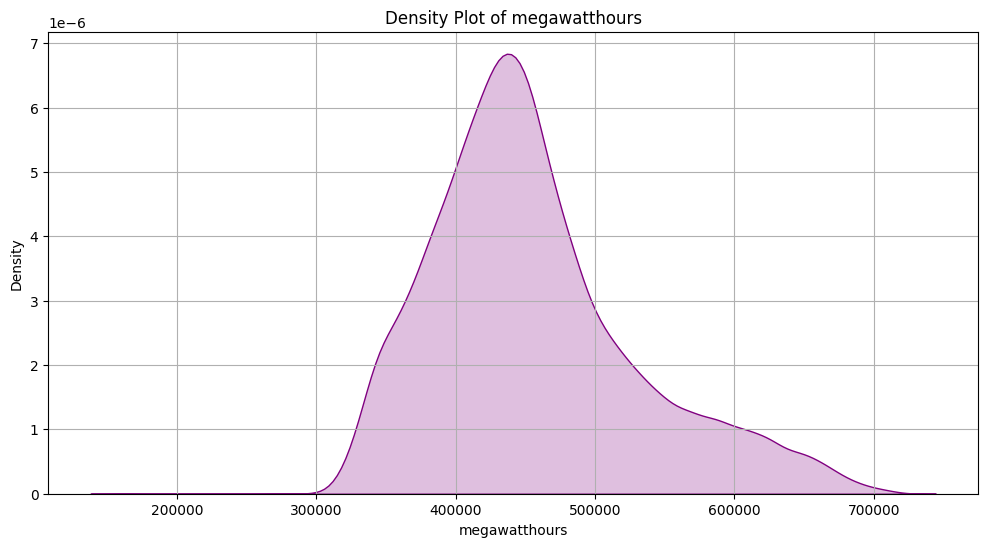

In [243]:
# Loop through each column and plot KDE
plt.figure(figsize=(12, 6))
sns.kdeplot(df['megawatthours'], shade=True, color='purple')
plt.title(f'Density Plot of megawatthours')
plt.xlabel('megawatthours')
plt.ylabel('Density')
plt.grid(True)
plt.show()

### histograms

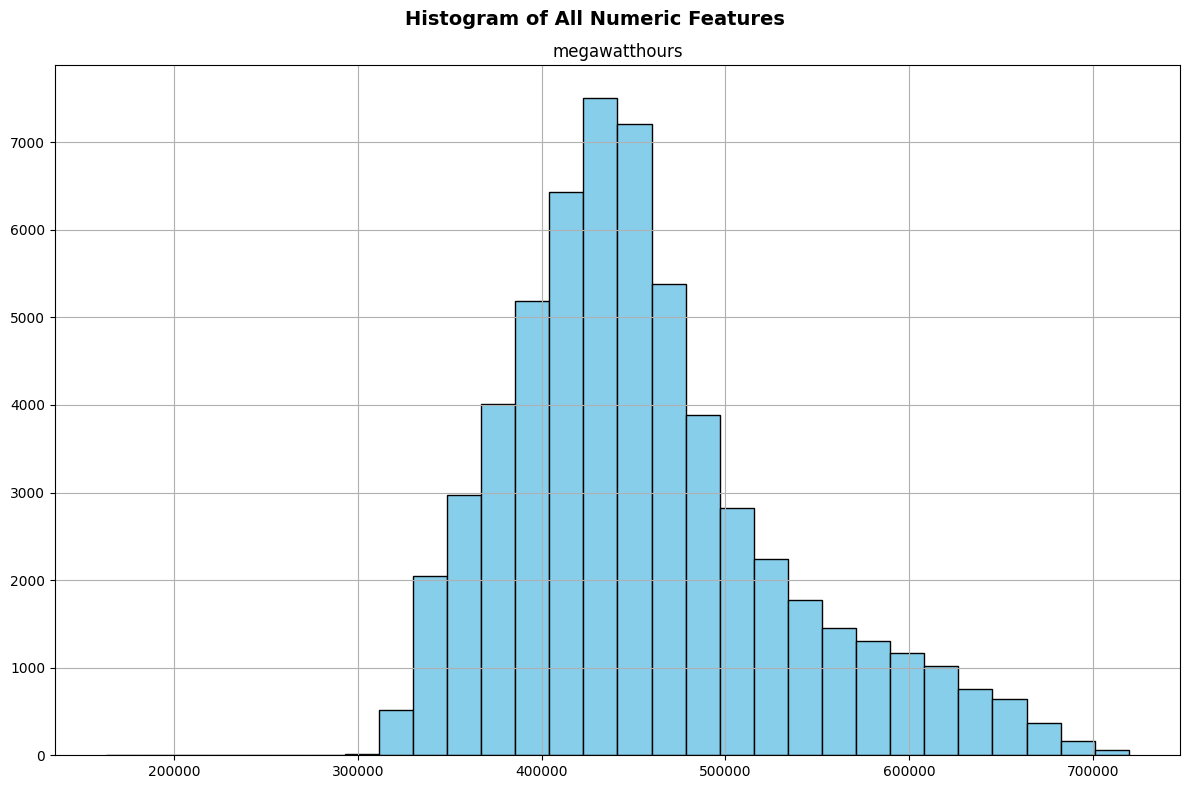

In [244]:
df.hist(figsize=(12, 8), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Histogram of All Numeric Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [245]:
# Core Data Check / Validation
print("🔍 Core Data Validation")
print("Shape:", df.shape)
print("Data Types:\n", df.dtypes)
print("Missing Values:\n", df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Columns Names", df.columns)

🔍 Core Data Validation
Shape: (58936, 2)
Data Types:
 date             object
megawatthours     int64
dtype: object
Missing Values:
 date             0
megawatthours    0
dtype: int64
Duplicate Rows: 0
Columns Names Index(['date', 'megawatthours'], dtype='object')


#### to_datetime

In [246]:
# Ensure datetime is parsed
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M', errors='coerce')

In [247]:
df

,date,megawatthours
0,2015-07-01 05:00:00,162827
1,2015-07-01 06:00:00,335153
2,2015-07-01 07:00:00,333837
3,2015-07-01 08:00:00,398386
4,2015-07-01 09:00:00,388954
...,...,...
58931,2022-03-21 16:00:00,433344
58932,2022-03-21 17:00:00,429156
58933,2022-03-21 18:00:00,426496
58934,2022-03-21 19:00:00,423393


### Core time features

In [248]:
# ===== CORE TIME FEATURES =====
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['day_of_month'] = df['date'].dt.day
df['day_of_year'] = df['date'].dt.dayofyear

In [249]:
df

,date,megawatthours,hour,day_of_week,day_of_month,day_of_year
0,2015-07-01 05:00:00,162827,5,2,1,182
1,2015-07-01 06:00:00,335153,6,2,1,182
2,2015-07-01 07:00:00,333837,7,2,1,182
3,2015-07-01 08:00:00,398386,8,2,1,182
4,2015-07-01 09:00:00,388954,9,2,1,182
...,...,...,...,...,...,...
58931,2022-03-21 16:00:00,433344,16,0,21,80
58932,2022-03-21 17:00:00,429156,17,0,21,80
58933,2022-03-21 18:00:00,426496,18,0,21,80
58934,2022-03-21 19:00:00,423393,19,0,21,80


In [250]:
df.columns

Index(['date', 'megawatthours', 'hour', 'day_of_week', 'day_of_month',
       'day_of_year'],
      dtype='object')

#### EDA Analysis

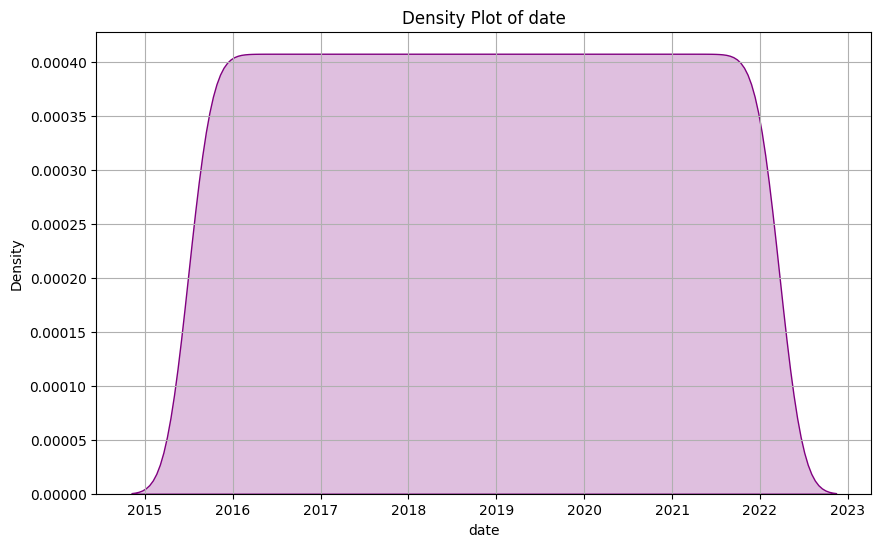

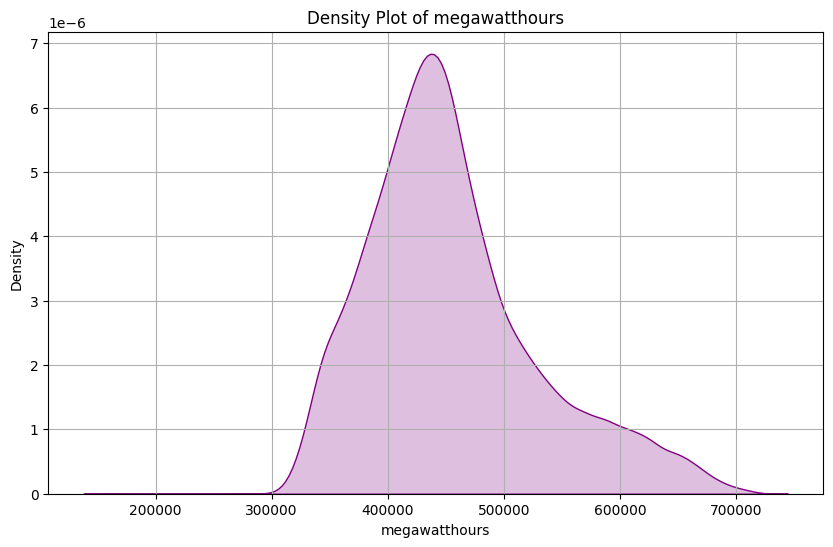

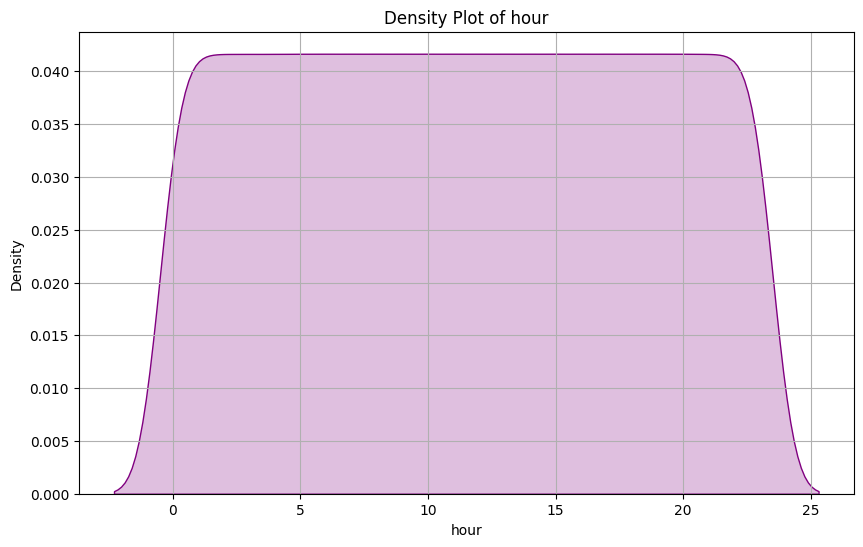

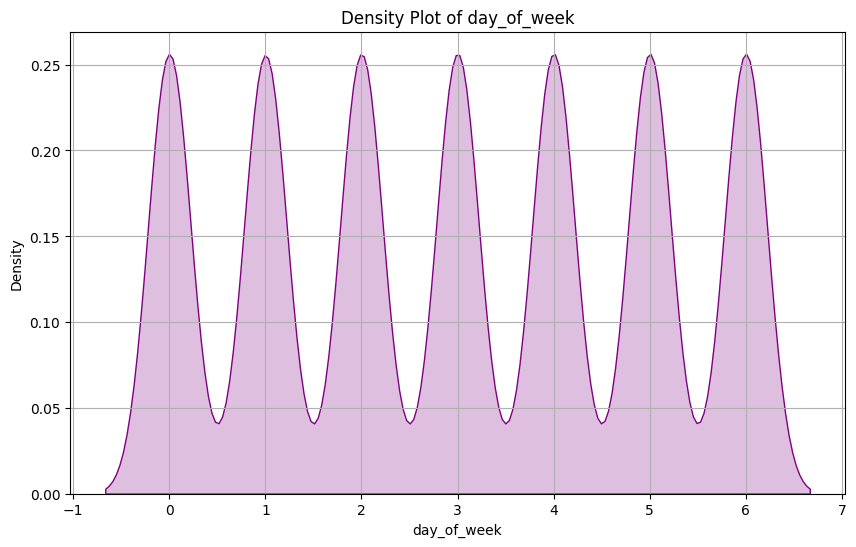

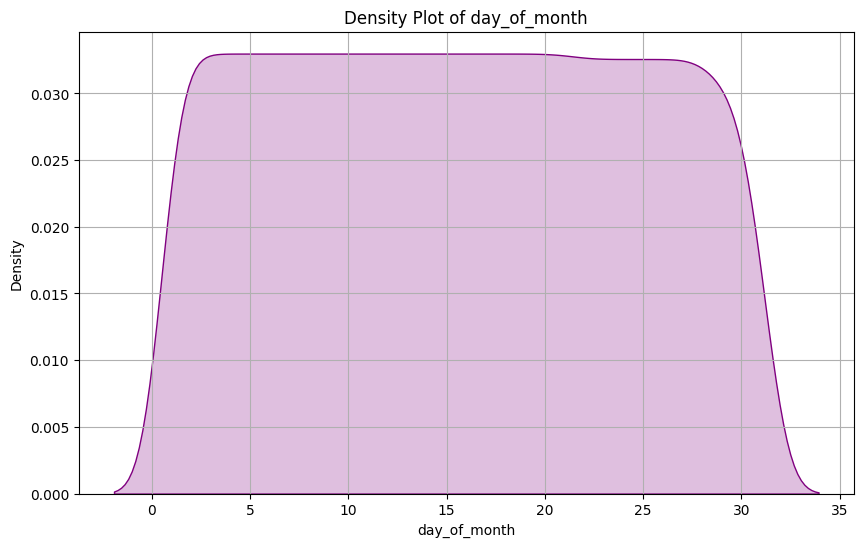

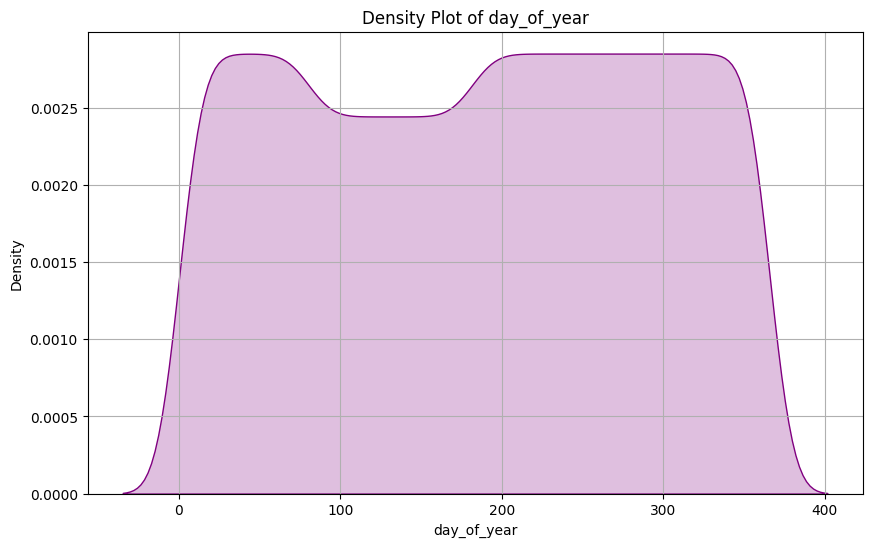

In [251]:


# List of columns to plot
columns_to_plot = ['date', 'megawatthours', 'hour', 'day_of_week', 'day_of_month',
       'day_of_year']

# Loop through each column and plot KDE
for col in columns_to_plot:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(df[col], shade=True, color='purple')
    plt.title(f'Density Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.grid(True)
    plt.show()

In [252]:
df

,date,megawatthours,hour,day_of_week,day_of_month,day_of_year
0,2015-07-01 05:00:00,162827,5,2,1,182
1,2015-07-01 06:00:00,335153,6,2,1,182
2,2015-07-01 07:00:00,333837,7,2,1,182
3,2015-07-01 08:00:00,398386,8,2,1,182
4,2015-07-01 09:00:00,388954,9,2,1,182
...,...,...,...,...,...,...
58931,2022-03-21 16:00:00,433344,16,0,21,80
58932,2022-03-21 17:00:00,429156,17,0,21,80
58933,2022-03-21 18:00:00,426496,18,0,21,80
58934,2022-03-21 19:00:00,423393,19,0,21,80


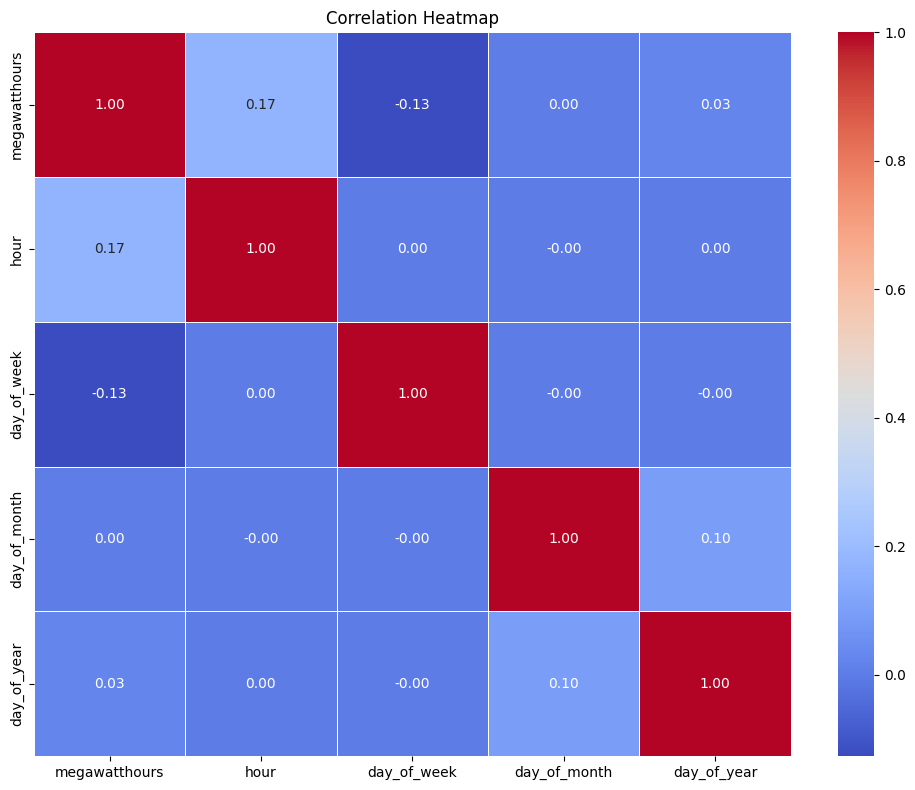

In [253]:
# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

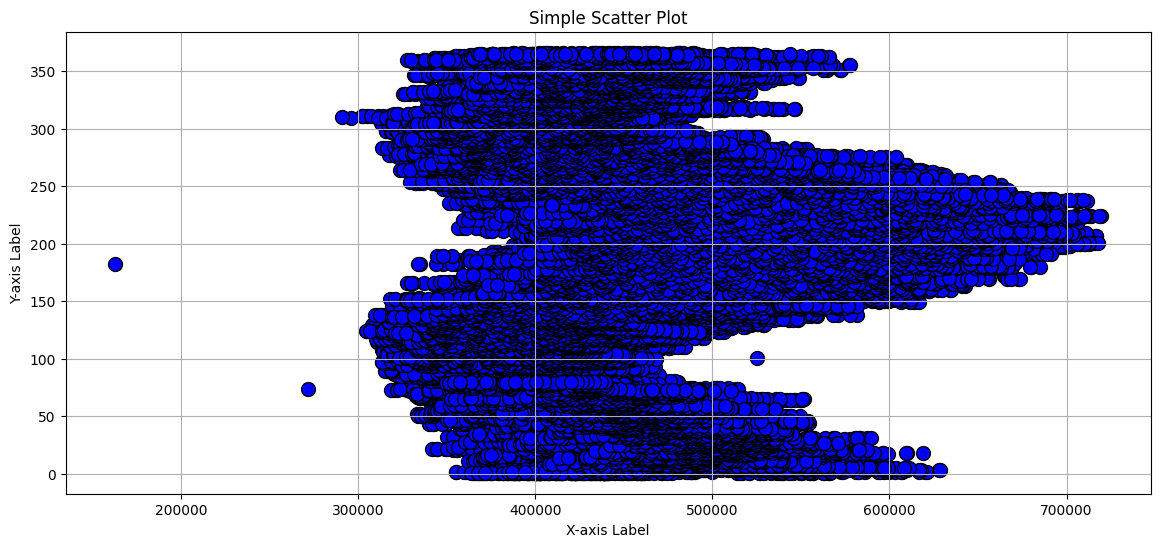

In [254]:
# Create scatter plot
plt.figure(figsize=(14, 6))  # Optional: enlarge canvas
plt.scatter(df['megawatthours'], df['day_of_year'], color='blue', marker='o', s=100, edgecolors='black')

# Add labels and title
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Simple Scatter Plot')

# Show plot
plt.grid(True)
plt.show()

### Handling Outliers

Total data points: 58936
Outliers detected: 2242
Outlier values: [162827, 623522, 623216, 640279, 652235, 660073, 663547, 658633, 645083, 623910, 630055, 641020, 647899, 649879, 642669, 630109, 623298, 626393, 629297, 637152, 638748, 630664, 625014, 631301, 629503, 624323, 648418, 668585, 677361, 682785, 683238, 677092, 662509, 647155, 628903, 634703, 644857, 649742, 649781, 642770, 626221, 624897, 633022, 634930, 626969, 633831, 641648, 643880, 637585, 624131, 626291, 638350, 646847, 649685, 643248, 627383, 623908, 623575, 643959, 662301, 674114, 681558, 684292, 678654, 665324, 650340, 633854, 637340, 662723, 681189, 693716, 701269, 702262, 695909, 681178, 661219, 643534, 636701, 661416, 681173, 693055, 697737, 700172, 695396, 681609, 666056, 647241, 628494, 653672, 671434, 682163, 688288, 689487, 682378, 666540, 649856, 632088, 629510, 649445, 663258, 671328, 672025, 661287, 640359, 623459, 626464, 623052, 624706, 622905, 623169, 641028, 659147, 668028, 673043, 673106, 664723, 650394

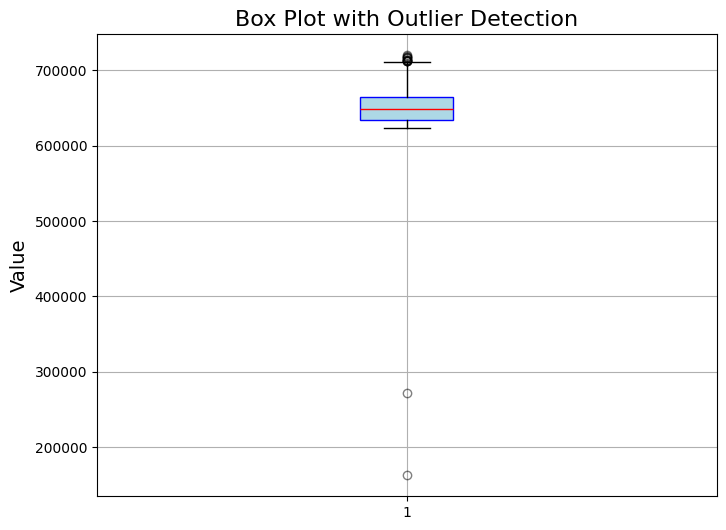

In [255]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to NumPy array for calculations
data_array = np.array(df['megawatthours'])

# Calculate Q1, Q3, and IQR
Q1 = np.percentile(data_array, 25)
Q3 = np.percentile(data_array, 75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = data_array[(data_array < lower_bound) | (data_array > upper_bound)]

# Print outlier info
print(f"Total data points: {len(data_array)}")
print(f"Outliers detected: {len(outliers)}")
print(f"Outlier values: {outliers.tolist()}")
print(f"Outlier values Len: {len(outliers)}")

# Create box plot
plt.figure(figsize=(8, 6))
plt.boxplot(outliers, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(marker='o', color='orange', alpha=0.5))

# Add title and labels
plt.title('Box Plot with Outlier Detection', fontsize=16)
plt.ylabel('Value', fontsize=14)
plt.grid(True)
plt.show()

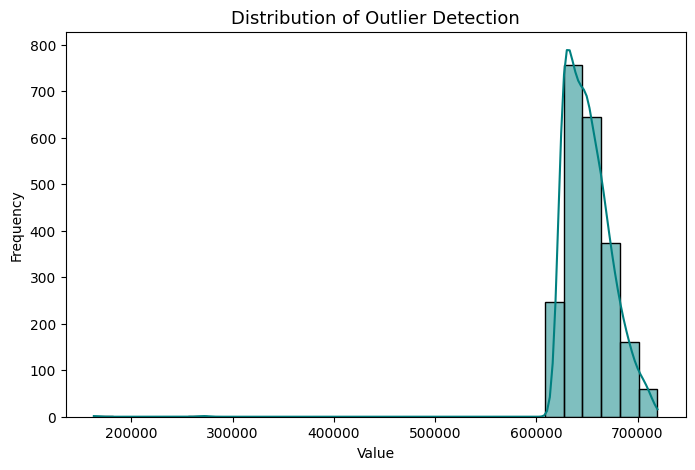

In [256]:
# -----------------------------------------------
# 2️⃣ Histogram for a Single Column
# -----------------------------------------------
plt.figure(figsize=(8, 5))
sns.histplot(data = outliers, bins=30, kde=True, color='teal')
plt.title("Distribution of Outlier Detection", fontsize=13)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

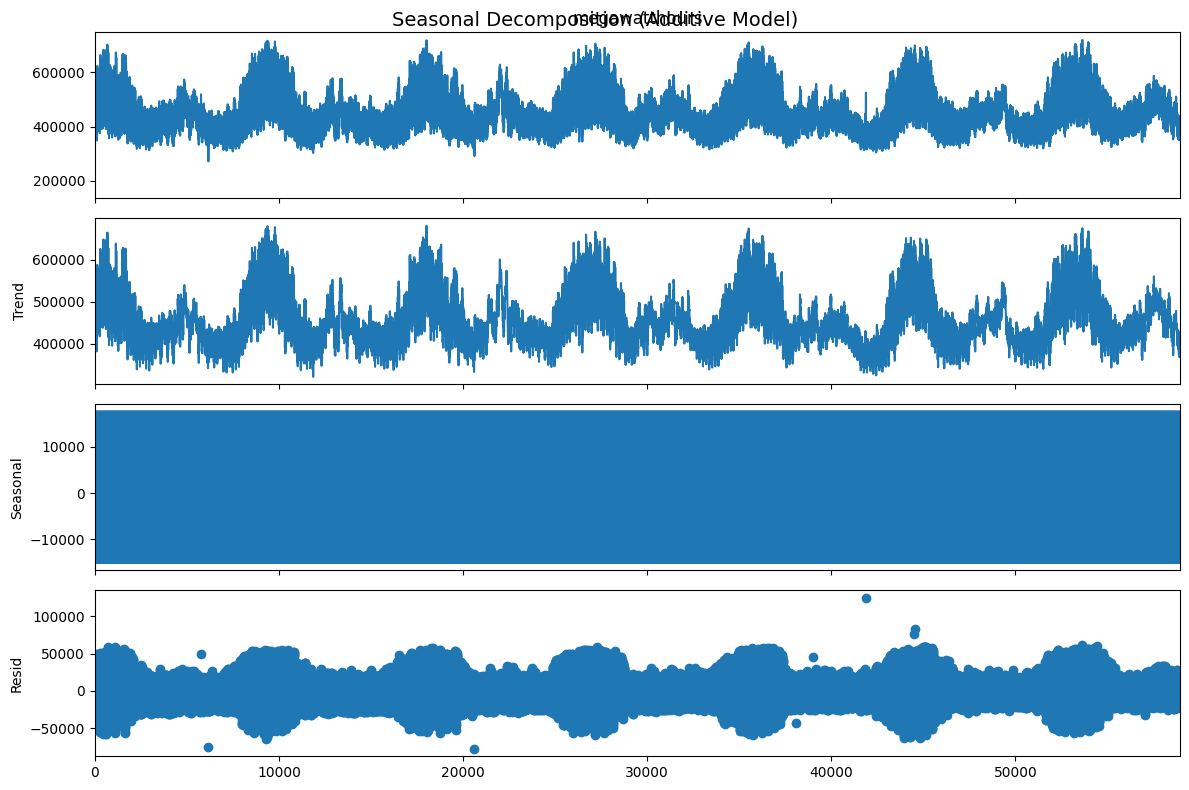

Trend Component:
 6     411951.541667
7     437086.333333
8     456590.958333
9     474573.541667
10    491012.791667
Name: trend, dtype: float64

Seasonal Component:
 0     1263.646457
1    -5912.377126
2   -11209.995804
3   -14485.472424
4   -15073.484280
Name: seasonal, dtype: float64

Residual Component:
 6     -2943.750066
7    -20408.525035
8    -28181.277207
9    -27763.451739
10   -15073.963879
Name: resid, dtype: float64


In [257]:
# ===========================================
# SEASONAL DECOMPOSITION (Trend, Seasonality, Residual)
# ===========================================

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Example: Load time series data (ensure it has a datetime index)
# Replace with your dataset
# df = pd.read_csv('your_timeseries.csv', parse_dates=['date'], index_col='date')

# Example: Select a numeric column to analyze
ts = df['megawatthours']   # Replace with your target column name

# Perform seasonal decomposition
# Model: 'additive' or 'multiplicative'
# Period: number of observations per cycle (e.g., 12 for monthly data, 7 for weekly)
result = seasonal_decompose(ts, model='additive', period=12)

# Plot the decomposition results
plt.rcParams.update({'figure.figsize': (12, 8)})
result.plot()
plt.suptitle('Seasonal Decomposition (Additive Model)', fontsize=14)
plt.show()

# Optional: Access individual components
trend = result.trend
seasonal = result.seasonal
residual = result.resid

# Print summary statistics
print("Trend Component:\n", trend.dropna().head())
print("\nSeasonal Component:\n", seasonal.dropna().head())
print("\nResidual Component:\n", residual.dropna().head())



In [258]:
df.shape

(58936, 6)

In [259]:
df.columns

Index(['date', 'megawatthours', 'hour', 'day_of_week', 'day_of_month',
       'day_of_year'],
      dtype='object')

Manual Outlier Cutoffs → Lower: 300000, Upper: 650000
Original Shape: (58936, 6)
Filtered Shape: (57882, 6)


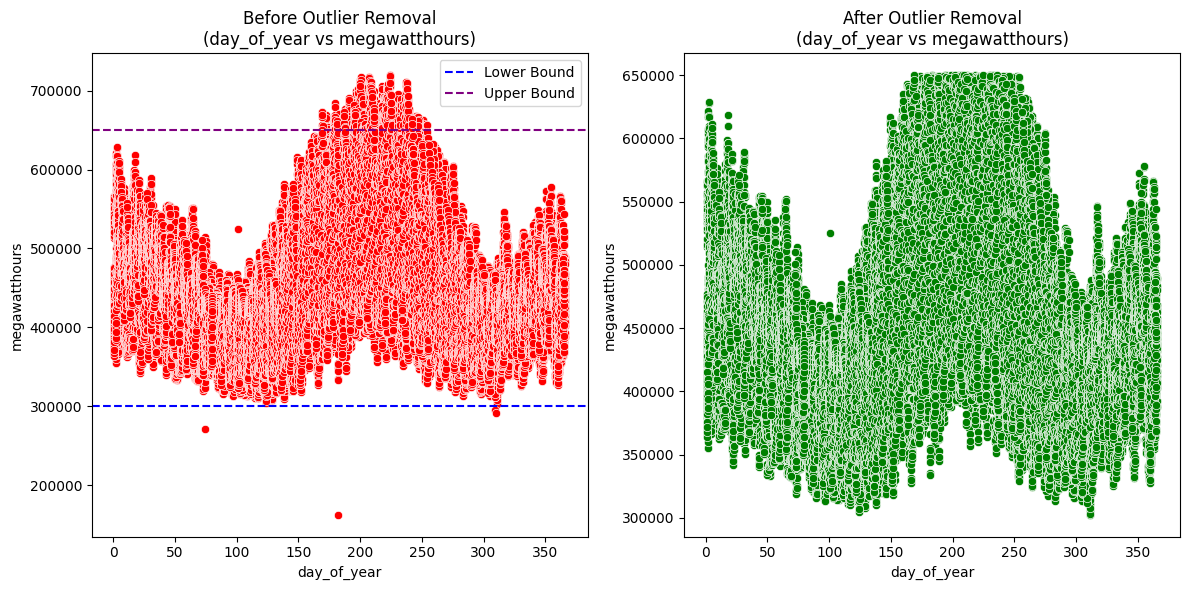

In [260]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Define your columns ---
target_col = 'megawatthours'        # 🔁 your target column
X_feature = 'day_of_year'    # 🔁 your x-axis feature (e.g., 'humidity', 'day', etc.)

# --- Step 2: Define manual cutoff values ---
lowerbound = 300000     # 👈 set your lower limit
upperbound = 650000    # 👈 set your upper limit

# --- Step 3: Apply filtering based on manual cutoffs ---
new_df = df[(df[target_col] >= lowerbound) & (df[target_col] <= upperbound)]

print(f"Manual Outlier Cutoffs → Lower: {lowerbound}, Upper: {upperbound}")
print("Original Shape:", df.shape)
print("Filtered Shape:", new_df.shape)

# --- Step 4: Scatter Plot Visualization ---
plt.figure(figsize=(12, 6))

# Before outlier removal
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x=X_feature, y=target_col, color='red', alpha=1)
plt.axhline(lowerbound, color='blue', linestyle='--', label='Lower Bound')
plt.axhline(upperbound, color='purple', linestyle='--', label='Upper Bound')
plt.legend()
plt.title(f"Before Outlier Removal\n({X_feature} vs {target_col})")

# After outlier removal
plt.subplot(1, 2, 2)
sns.scatterplot(data=new_df, x=X_feature, y=target_col, color='green', alpha=1)
plt.title(f"After Outlier Removal\n({X_feature} vs {target_col})")

plt.tight_layout()
plt.show()



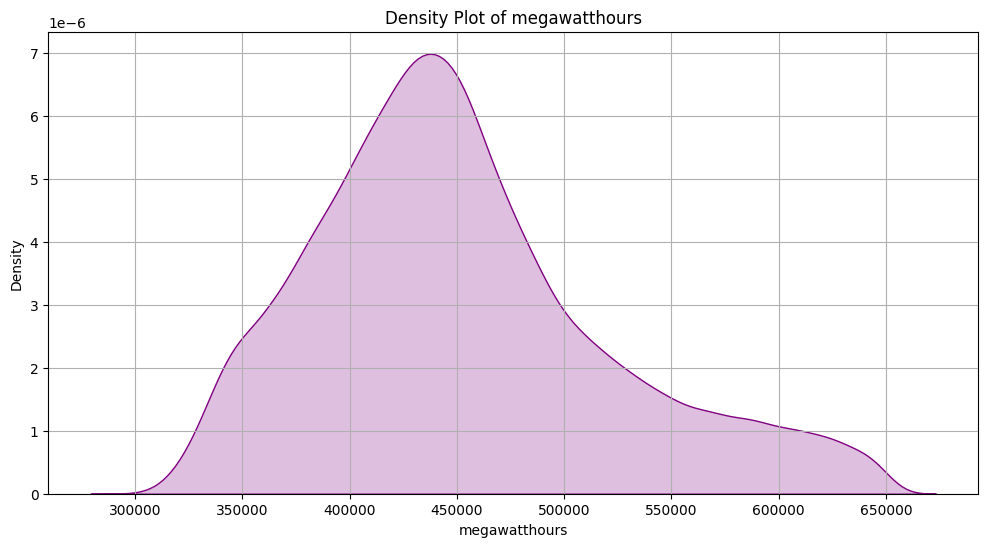

In [261]:
# Loop through each column and plot KDE
plt.figure(figsize=(12, 6))
sns.kdeplot(new_df['megawatthours'], shade=True, color='purple')
plt.title(f'Density Plot of megawatthours')
plt.xlabel('megawatthours')
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [262]:
import pandas as pd


# Function to remove outliers using IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Call the function
df_clean = remove_outliers_iqr(df, 'megawatthours')


In [263]:
df_clean

,date,megawatthours,hour,day_of_week,day_of_month,day_of_year
1,2015-07-01 06:00:00,335153,6,2,1,182
2,2015-07-01 07:00:00,333837,7,2,1,182
3,2015-07-01 08:00:00,398386,8,2,1,182
4,2015-07-01 09:00:00,388954,9,2,1,182
5,2015-07-01 10:00:00,392487,10,2,1,182
...,...,...,...,...,...,...
58931,2022-03-21 16:00:00,433344,16,0,21,80
58932,2022-03-21 17:00:00,429156,17,0,21,80
58933,2022-03-21 18:00:00,426496,18,0,21,80
58934,2022-03-21 19:00:00,423393,19,0,21,80


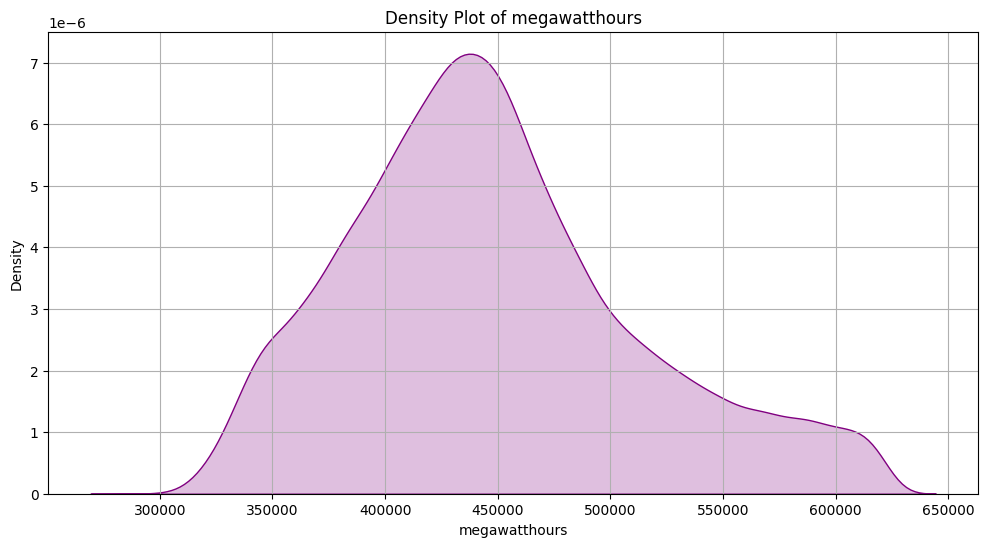

In [264]:
# Loop through each column and plot KDE
plt.figure(figsize=(12, 6))
sns.kdeplot(df_clean['megawatthours'], shade=True, color='purple')
plt.title(f'Density Plot of megawatthours')
plt.xlabel('megawatthours')
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [265]:
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
date,56694,2018-11-11 16:23:47.452640512,2015-07-01 06:00:00,2017-03-08 09:15:00,2018-11-13 21:30:00,2020-07-14 10:45:00,2022-03-21 20:00:00,NaN
megawatthours,56694.0,447474.846721,291060.0,402234.0,440355.5,483636.5,622620.0,64910.735147
hour,56694.0,11.313649,0.0,5.0,11.0,17.0,23.0,6.780731
day_of_week,56694.0,3.025523,0.0,1.0,3.0,5.0,6.0,2.008721
day_of_month,56694.0,15.644636,1.0,8.0,16.0,23.0,31.0,8.800998
day_of_year,56694.0,184.29467,1.0,86.0,185.0,281.0,366.0,108.782196


In [266]:
df_clean.head(2)

,date,megawatthours,hour,day_of_week,day_of_month,day_of_year
1,2015-07-01 06:00:00,335153,6,2,1,182
2,2015-07-01 07:00:00,333837,7,2,1,182


## variance threshold

Feature Variances:
 megawatthours    4.213404e+09
hour             4.597832e+01
day_of_week      4.034961e+00
day_of_month     7.745756e+01
day_of_year      1.183357e+04
dtype: float64

Selected Features (Variance > threshold):
['megawatthours', 'hour', 'day_of_week', 'day_of_month', 'day_of_year']

Original shape: (56694, 5)
Reduced shape: (56694, 5)


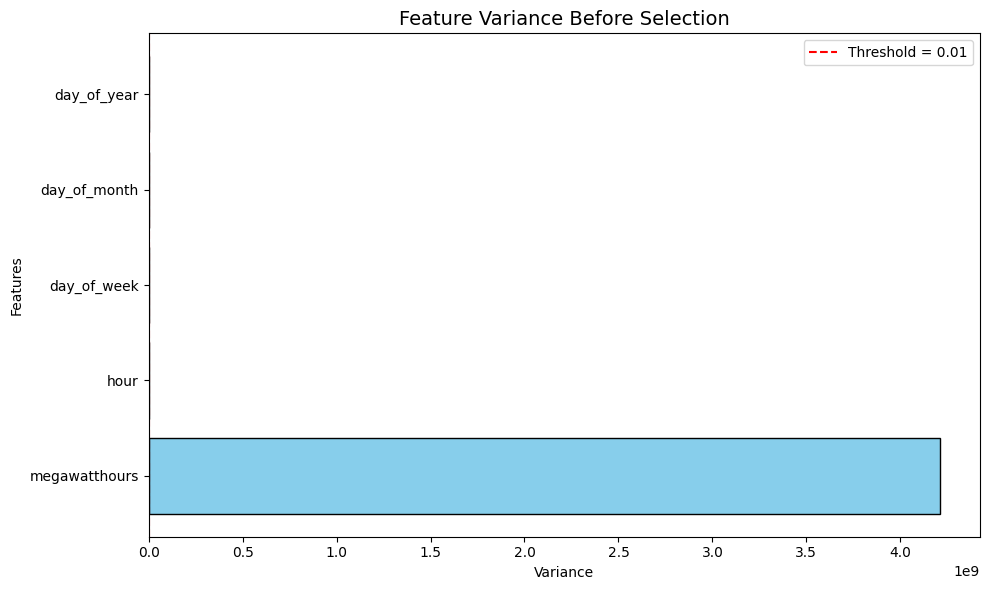

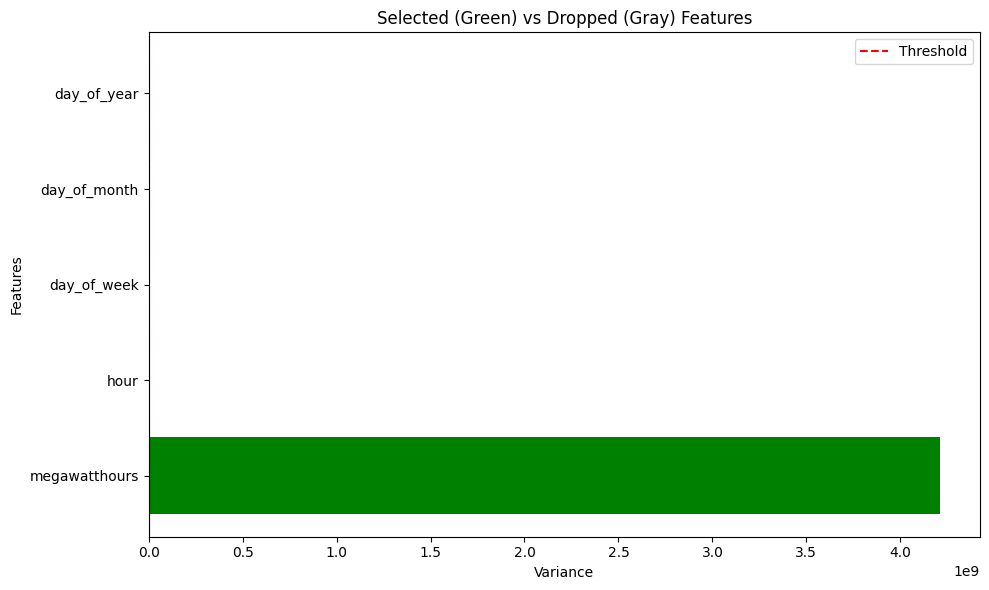

In [267]:
# ============================================
# VARIANCE THRESHOLD FEATURE SELECTION
# ============================================

# 0.0	Removes features with zero variance (constant values)	Basic cleanup
# >0.01	Removes features with very low variance	Useful for high-dimensional data
# 0.1–0.2	Aggressive filtering	Use with caution; may remove informative features

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

# ----- STEP 1: Load or prepare clean dataset -----
# Assume df is your clean DataFrame
# Example: df = pd.read_csv('data.csv')

# Remove non-numeric columns if present
dfnumeric = df_clean.select_dtypes(include=[np.number])

# ----- STEP 2: Check variance of all features -----
feature_variances = dfnumeric.var()
print("Feature Variances:\n", feature_variances)

# ----- STEP 3: Apply VarianceThreshold -----
threshold = 0.01  # you can adjust this value (e.g., 0.0, 0.01, 0.02)
selector = VarianceThreshold(threshold=threshold)
X_selected = selector.fit_transform(dfnumeric)

# Get selected feature names
selected_features = dfnumeric.columns[selector.get_support()]
print("\nSelected Features (Variance > threshold):")
print(selected_features.tolist())

# ----- STEP 4: Create a new filtered DataFrame -----
df_selected = dfnumeric[selected_features]
print(f"\nOriginal shape: {dfnumeric.shape}")
print(f"Reduced shape: {df_selected.shape}")

# ----- STEP 5: Visualization - Variance Comparison -----
plt.figure(figsize=(10, 6))
plt.barh(dfnumeric.columns, feature_variances, color='skyblue', edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
plt.title('Feature Variance Before Selection', fontsize=14)
plt.xlabel('Variance')
plt.ylabel('Features')
plt.legend()
plt.tight_layout()
plt.show()

# ----- STEP 6: Visualization - Selected vs Dropped -----
plt.figure(figsize=(10, 6))
selected_mask = selector.get_support()
colors = ['green' if selected else 'gray' for selected in selected_mask]
plt.barh(dfnumeric.columns, feature_variances, color=colors)
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
plt.title('Selected (Green) vs Dropped (Gray) Features')
plt.xlabel('Variance')
plt.ylabel('Features')
plt.legend()
plt.tight_layout()
plt.show()



## Variance Inflation Factor (VIF)

In [268]:
df_clean.columns

Index(['date', 'megawatthours', 'hour', 'day_of_week', 'day_of_month',
       'day_of_year'],
      dtype='object')


✅ Features selected for VIF calculation (excluding target 'megawatthours'):
['hour', 'day_of_week', 'day_of_month', 'day_of_year']

📊 Variance Inflation Factor (VIF) Results:

        Feature        VIF
0         const  11.509541
1   day_of_year   1.009803
2  day_of_month   1.009758
3          hour   1.000231
4   day_of_week   1.000194

⚠️ Features with high multicollinearity (VIF > 10):
  Feature        VIF
0   const  11.509541


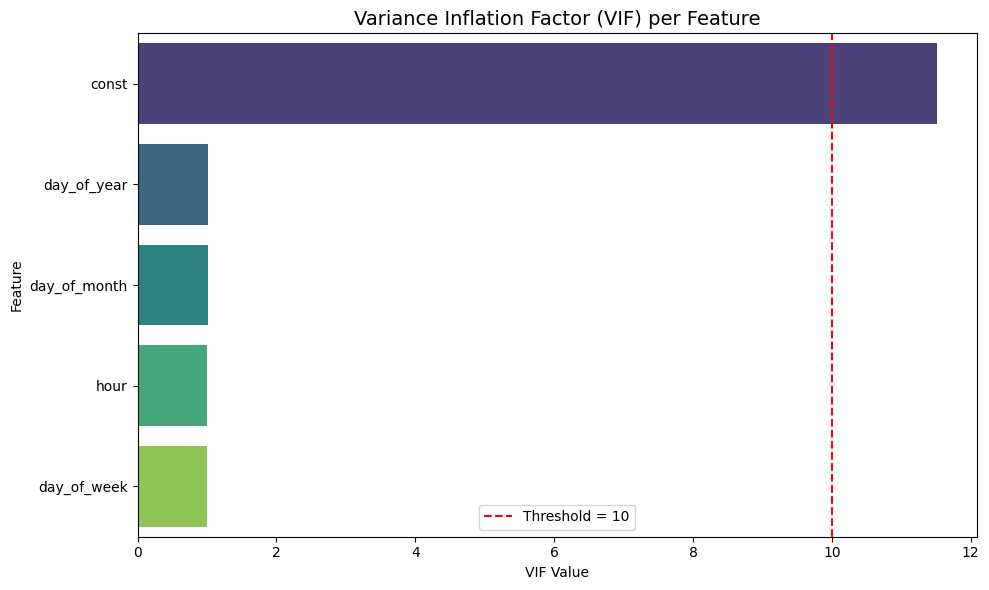

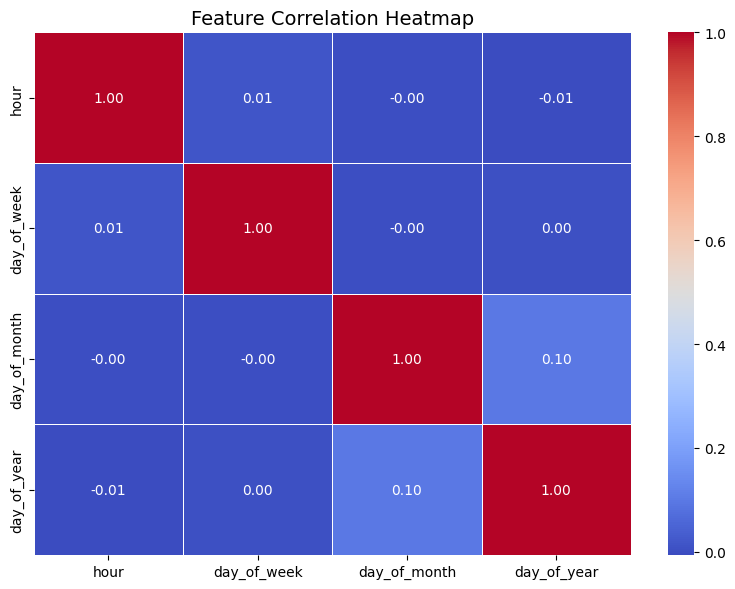

In [269]:
# ============================================
# MULTICOLLINEARITY CHECK USING VIF (V & I Separated)
# ============================================
# Guide:
#  VIF < 5   → Low to moderate multicollinearity (acceptable)
#  5 ≤ VIF ≤ 10 → High multicollinearity (monitor carefully)
#  VIF > 10  → Very high multicollinearity (consider feature removal)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant  # ✅ Added for VIF stability

# ----- STEP 1: Prepare Data -----
target_column = 'megawatthours'  # 🔁 Change this to your actual target column
df_model = df_clean.copy()

# Separate V (features) and I (target)
V = df_model.drop(columns=[target_column], errors='ignore')
I = df_model[target_column] if target_column in df_model.columns else None

# Ensure V has only numeric features and no missing values
V = V.select_dtypes(include=[np.number]).dropna()

# Add constant to stabilize VIF calculation
V_const = add_constant(V)

print(f"\n✅ Features selected for VIF calculation (excluding target '{target_column}'):")
print(list(V.columns))

# ----- STEP 2: Compute VIF -----
vif_data = pd.DataFrame()
vif_data["Feature"] = V_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(V_const.values, i)
    for i in range(V_const.shape[1])
]

# ----- STEP 3: Sort by VIF -----
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
print("\n📊 Variance Inflation Factor (VIF) Results:\n")
print(vif_data)

# ----- STEP 4: Identify high-VIF features -----
high_vif = vif_data[vif_data["VIF"] > 10]
if not high_vif.empty:
    print("\n⚠️ Features with high multicollinearity (VIF > 10):")
    print(high_vif)
else:
    print("\n✅ No features with critical multicollinearity detected (VIF ≤ 10).")

# ----- STEP 5: Visualization — VIF Bar Chart -----
plt.figure(figsize=(10, 6))
sns.barplot(x="VIF", y="Feature", data=vif_data, palette="viridis")
plt.axvline(10, color='red', linestyle='--', label='Threshold = 10')
plt.title("Variance Inflation Factor (VIF) per Feature", fontsize=14)
plt.xlabel("VIF Value")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()
plt.show()

# ----- STEP 6: Visualization — Correlation Heatmap -----
plt.figure(figsize=(8, 6))
sns.heatmap(V.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()


## Statistical Tests ANOVA

=== ANOVA F-Test Feature Scores ===
        Feature   F_Score   P_Value
0          hour  1.055707  0.001719
1   day_of_week  1.040315  0.016350
2  day_of_month  0.991128  0.688033
3   day_of_year  0.930974  0.999958


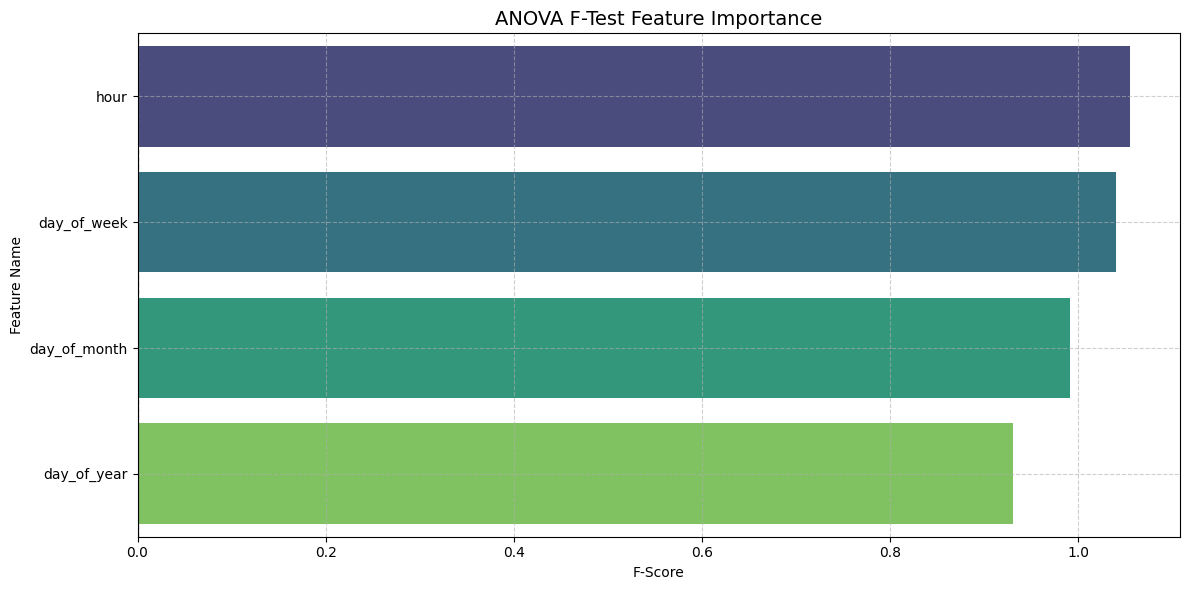


✅ Significant Features (p < 0.05):
['hour', 'day_of_week']


In [270]:
# ==============================================
# ANOVA F-Test Feature Selection with Visualization
# ==============================================
# Select features with:
# - High F-score
# - Low p-value (typically < 0.05)

import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# STEP 1: Load Data
# -------------------------------
# Separate features and target
target_column = "megawatthours"  # Replace with your actual target column
anova_X = df_clean.drop(columns=[target_column], errors='ignore')
anova_y = df_clean[target_column]

# Keep only numeric features
X_numeric = anova_X.select_dtypes(include=[np.number]).dropna()

# -------------------------------
# STEP 2: Apply ANOVA F-Test
# -------------------------------
selector = SelectKBest(score_func=f_classif, k='all')  # use 'all' to get all scores
X_new = selector.fit_transform(X_numeric, anova_y)

# Get feature scores and p-values
anova_scores = selector.scores_
anova_pvalues = selector.pvalues_

# Combine results into a DataFrame
anova_df = pd.DataFrame({
    'Feature': X_numeric.columns,
    'F_Score': anova_scores,
    'P_Value': anova_pvalues
}).sort_values(by='F_Score', ascending=False).reset_index(drop=True)

print("=== ANOVA F-Test Feature Scores ===")
print(anova_df)

# -------------------------------
# STEP 3: Visualization
# -------------------------------
plt.figure(figsize=(12, 6))
sns.barplot(x='F_Score', y='Feature', data=anova_df, palette='viridis')
plt.title("ANOVA F-Test Feature Importance", fontsize=14)
plt.xlabel("F-Score")
plt.ylabel("Feature Name")
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# -------------------------------
# STEP 4: Filter Important Features (Optional)
# -------------------------------
significant_features = anova_df[anova_df['P_Value'] < 0.05]['Feature']
print("\n✅ Significant Features (p < 0.05):")
print(significant_features.tolist())



## Feature engineering & Feature selection

In [271]:
# ===== CYCLIC (PERIODIC) FEATURES =====
df_clean['hour_sin'] = np.sin(2 * np.pi * df_clean['hour'] / 24)
df_clean['hour_cos'] = np.cos(2 * np.pi * df_clean['hour'] / 24)
df_clean['dayofweek_sin'] = np.sin(2 * np.pi * df_clean['day_of_week'] / 7)
df_clean['dayofweek_cos'] = np.cos(2 * np.pi * df_clean['day_of_week'] / 7)
df_clean['dayofmonth_sin'] = np.sin(2 * np.pi * (df_clean['day_of_month'] - 1) / 31)
df_clean['dayofmonth_cos'] = np.cos(2 * np.pi * (df_clean['day_of_month'] - 1) / 31)
df_clean['dayofyear_sin'] = np.sin(2 * np.pi * (df_clean['day_of_year'] - 1) / 365)
df_clean['dayofyear_cos'] = np.cos(2 * np.pi * (df_clean['day_of_year'] - 1) / 365)


In [272]:
df_clean.head(2)

,date,megawatthours,hour,day_of_week,day_of_month,day_of_year,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos
1,2015-07-01 06:00:00,335153,6,2,1,182,1.000000,6.123234e-17,0.974928,-0.222521,0.0,1.0,0.025818,-0.999667
2,2015-07-01 07:00:00,333837,7,2,1,182,0.965926,-2.588190e-01,0.974928,-0.222521,0.0,1.0,0.025818,-0.999667


## corrmatrix 


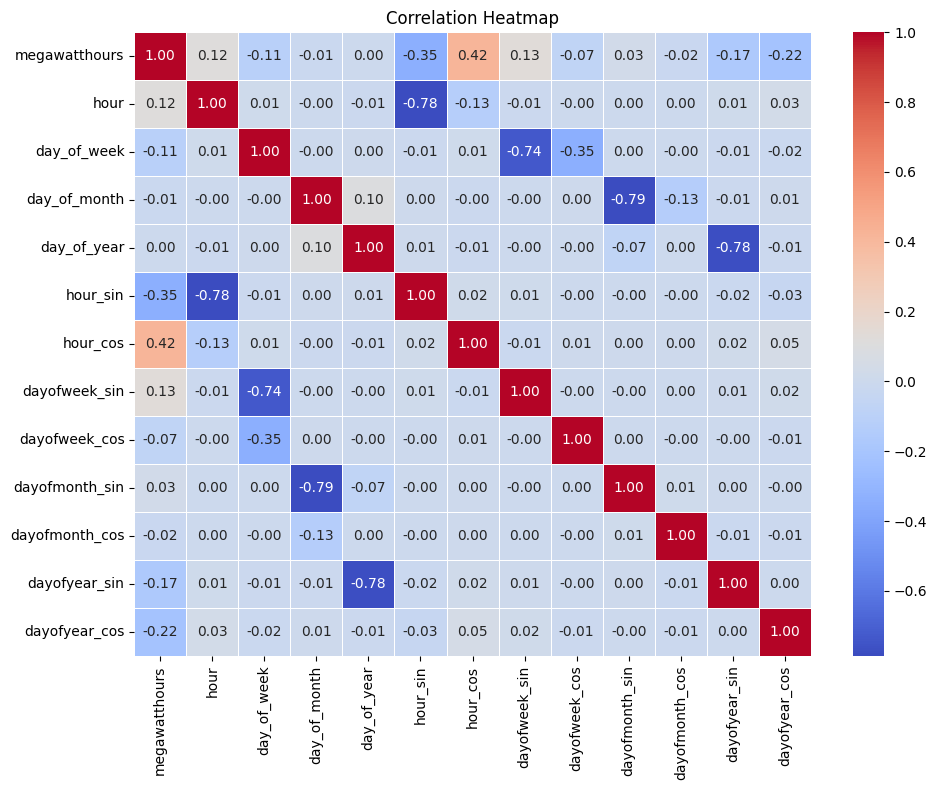

In [273]:
# Compute correlation matrix
corrmatrix01 = df_clean.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corrmatrix01, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [274]:
df_clean.columns

Index(['date', 'megawatthours', 'hour', 'day_of_week', 'day_of_month',
       'day_of_year', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos',
       'dayofmonth_sin', 'dayofmonth_cos', 'dayofyear_sin', 'dayofyear_cos'],
      dtype='object')

In [276]:
df_clean.drop(columns=['hour', 'day_of_week', 'day_of_month','day_of_year'], axis=1, inplace=True)

In [277]:
df_clean

,date,megawatthours,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos
1,2015-07-01 06:00:00,335153,1.000000,6.123234e-17,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
2,2015-07-01 07:00:00,333837,0.965926,-2.588190e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
3,2015-07-01 08:00:00,398386,0.866025,-5.000000e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
4,2015-07-01 09:00:00,388954,0.707107,-7.071068e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
5,2015-07-01 10:00:00,392487,0.500000,-8.660254e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
...,...,...,...,...,...,...,...,...,...,...
58931,2022-03-21 16:00:00,433344,-0.866025,-5.000000e-01,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315
58932,2022-03-21 17:00:00,429156,-0.965926,-2.588190e-01,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315
58933,2022-03-21 18:00:00,426496,-1.000000,-1.836970e-16,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315
58934,2022-03-21 19:00:00,423393,-0.965926,2.588190e-01,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315


In [278]:
df_clean.set_index('date', inplace=True)

In [281]:
df_clean

,megawatthours,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos
date,,,,,,,,,
2015-07-01 06:00:00,335153,1.000000,6.123234e-17,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
2015-07-01 07:00:00,333837,0.965926,-2.588190e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
2015-07-01 08:00:00,398386,0.866025,-5.000000e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
2015-07-01 09:00:00,388954,0.707107,-7.071068e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
2015-07-01 10:00:00,392487,0.500000,-8.660254e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
...,...,...,...,...,...,...,...,...,...
2022-03-21 16:00:00,433344,-0.866025,-5.000000e-01,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315
2022-03-21 17:00:00,429156,-0.965926,-2.588190e-01,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315
2022-03-21 18:00:00,426496,-1.000000,-1.836970e-16,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315


 ## Model Selection & Cross-Validation & Train-Test Split

X_train: (45355, 8), X_test: (11339, 8)
✅ Target scaling completed successfully (X not scaled).
Training Sequence Shape: (45348, 7, 8)
Testing Sequence Shape:  (11332, 7, 8)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 64)          │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 7, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,385 (134.32 KB)

 Trainable params: 34,385 (134.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0131 - mae: 0.0838 - val_loss: 0.0074 - val_mae: 0.0692
Epoch 2/30
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0069 - mae: 0.0637 - val_loss: 0.0072 - val_mae: 0.0673
Epoch 3/30
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0063 - mae: 0.0607 - val_loss: 0.0067 - val_mae: 0.0647
Epoch 4/30
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0060 - mae: 0.0586 - val_loss: 0.0067 - val_mae: 0.0634
Epoch 5/30
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0058 - mae: 0.0576 - val_loss: 0.0066 - val_mae: 0.0648
Epoch 6/30
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0057 - mae: 0.0570 - val_loss: 0.0065 - val_mae: 0.0628
Epoch 7/30
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0055 - mae: 0.0561 - val_loss: 0.0076 - val_mae: 0.0687
Epoch 8/30
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0053 - mae: 0.0549 - val_loss: 0.0068 - val_mae: 0.0645
Epoch 9/30
1134/1134 ━━━━━━━━━━━━━━━━━━━

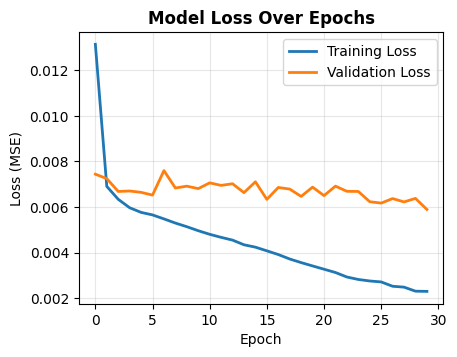

In [282]:
# ============================================
# IMPORTS
# ============================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ============================================
# STEP 1: DEFINE FEATURES AND TARGET
# ============================================
# Assuming df_clean is already loaded and cleaned
X = df_clean.drop(columns=['megawatthours'])  # Independent variables
y = df_clean['megawatthours']                 # Target variable

# ============================================
# STEP 2: TRAIN–TEST SPLIT (80-20)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

# ============================================
# STEP 3: SCALE ONLY THE TARGET VARIABLE (y)
# ============================================

# Initialize MinMaxScaler for target only
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Fit-transform on training target and transform on test target
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Keep X as-is (no scaling required)
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

print("✅ Target scaling completed successfully (X not scaled).")

# ============================================
# STEP 4: CREATE SEQUENCES AFTER SCALING
# ============================================
def create_sequences(X, y, seq_length=7):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X.iloc[i:i+seq_length].values)
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

seq_length = 7
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, seq_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, seq_length)

print(f"Training Sequence Shape: {X_train_seq.shape}")
print(f"Testing Sequence Shape:  {X_test_seq.shape}")

# ============================================
# STEP 5: BUILD LSTM MODEL
# ============================================
model = Sequential([
    LSTM(units=64, return_sequences=True, input_shape=(seq_length, X_train_seq.shape[2])),
    Dropout(0.2),

    LSTM(units=32, return_sequences=True),
    Dropout(0.2),

    LSTM(units=16, return_sequences=False),
    Dropout(0.2),

    Dense(units=8, activation='relu'),
    Dense(units=1, activation='linear')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# ============================================
# STEP 6: TRAIN MODEL
# ============================================
early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print(f"\n✅ Training completed at epoch {len(history.history['loss'])}")

# ============================================
# STEP 7: MAKE PREDICTIONS
# ============================================
y_train_pred_scaled = model.predict(X_train_seq, verbose=0)
y_test_pred_scaled = model.predict(X_test_seq, verbose=0)

# Inverse transform to original scale
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled).flatten()
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled).flatten()
y_train_actual = scaler_y.inverse_transform(y_train_seq).flatten()
y_test_actual = scaler_y.inverse_transform(y_test_seq).flatten()

# ============================================
# STEP 8: EVALUATE MODEL PERFORMANCE
# ============================================
def evaluate_model(y_true, y_pred, set_name=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n📊 {set_name} Metrics:")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

train_metrics = evaluate_model(y_train_actual, y_train_pred, "TRAINING SET")
test_metrics = evaluate_model(y_test_actual, y_test_pred, "TEST SET")
print(train_metrics)
print(test_metrics)

# 5. VISUALIZATIONS - MODEL PERFORMANCE

fig = plt.figure(figsize=(16, 12))

# 1. Training History - Loss
ax1 = plt.subplot(3, 3, 1)
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Model Loss Over Epochs', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)